In [1]:
import pickle
import pandas as pd
import json
from tqdm import tqdm
import numpy as np
import os
import sys
from IPython.display import display, Markdown
import logging
from pythonjsonlogger.json import JsonFormatter
import matplotlib.pyplot as plt

from typing import Dict, List


In [2]:
from adr import adr
import utils
from adr_topic_mining import ADRTopicModel

In [3]:
from dotenv import load_dotenv

# Configuring OpenAI (GPT)
print(load_dotenv())

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_MODEL_NAME"] =  os.getenv('OPENAI_MODEL_NAME') # 'gpt-4o-mini'
os.environ["EMBEDDINGS_MODEL"] = os.getenv("OPENAI_EMBEDDINGS_MODEL")
# OPENAI_API_KEY = None
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# print(os.environ["OPENAI_API_KEY"])
print(os.environ["OPENAI_MODEL_NAME"])
print(os.environ["EMBEDDINGS_MODEL"])

True
gpt-4.1-nano
text-embedding-3-small


In [4]:
# This is a dictionary with all the details of the ADRs, with a hierarchical organization
# that goes from the organization to its projects and finally the ADR files inside each project
ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle' 

TOPICS_FOLDER = "saved_topicmodel"
TOPICS_DATAFRAME = os.path.join(TOPICS_FOLDER, 'topics_dataframe.csv')

---

In [5]:
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path,'rb') as file:
    dict_adrs = pickle.load(file)
print(len(dict_adrs), "projects/organizations?")

547 projects/organizations?


In [6]:
def count_adrs(projects):
    count_adrs = 0
    for org, project in projects:
        adrs = dict_adrs[org][project]
        count_adrs += len(adrs)
    return count_adrs


projects_dict = utils.process_projects(dict_adrs, min_adrs_per_project=5, min_adr_length=500)
valid_projects = projects_dict['valid_projects']

print("Total number of ADRs: ", count_adrs(projects_dict['all_projects']))
print("Total number of valid ADRs: ", count_adrs(valid_projects))

organizations:   0%|          | 0/547 [00:00<?, ?it/s]

Total number of ADRs:  6061
Total number of valid ADRs:  4316


In [7]:
def get_text_column(df_texts,column='original_text'):
    tt = df_texts[column]
    if isinstance(tt.values[0],str):
        return tt.values.tolist()
    tt = [' '.join(x) for x in tt]
    return tt

def get_adr_texts(adrs_dict):
    """
    Get the text of the ADRs
    :param adrs_dict: dictionary with the ADRs
    :return: list of strings with the text of the ADRs
    """
    texts = []
    for org in adrs_dict.keys():
        for proj in adrs_dict[org].keys():
            adrs = list(adrs_dict[org][proj].values())
            texts.extend(adrs)
    return texts

docs = utils.get_documents(valid_projects, dict_adrs, verbose=False, field='content')
print("Number of documents (cleaned ADRs): ", len(docs))

Number of documents (cleaned ADRs):  4316


In [8]:
adr_topic_model = ADRTopicModel()

In [9]:
# adr_topic_model.prepare_corpus(docs)
# adr_topic_model.build(use_openai=True)

# In this case, an existing topic model is preloaded (alternatively, it can be built from scratch)
adr_topic_model.load(TOPICS_FOLDER)

,Topic,Count,Name,CustomName,Representation,OpenAI,Representative_Docs
0,-1,1514,-1_aws_deployment_cloud_services,Cloud Infrastructure and Deployment Decision-M...,"[aws, deployment, cloud, services, platform, s...",[Cloud Infrastructure and Deployment Decision-...,NaN
1,0,407,0_publishing_database_metadata_api,Software Architecture Decisions and Data Persi...,"[publishing, database, metadata, api, db, stor...",[Software Architecture Decisions and Data Pers...,NaN
2,1,257,1_fxa_jsx_framework_styles,Frontend architecture and UI component redesign,"[fxa, jsx, framework, styles, react, webpack, ...",[Frontend architecture and UI component redesign],NaN
3,2,213,2_architecture_decision_record_adrs_adr_archit...,Architectural Decision Records (ADR) Generatio...,"[architecture_decision_record, adrs, adr, arch...",[Architectural Decision Records (ADR) Generati...,NaN
4,3,109,3_kubernetes_kubectl_pods_pod,Kubernetes ingress and resource management str...,"[kubernetes, kubectl, pods, pod, ingress, aws,...",[Kubernetes ingress and resource management st...,NaN
...,...,...,...,...,...,...,...
68,67,12,67_microservices_microservice_monolithic_services,Software Architecture Decisions and Frameworks,"[microservices, microservice, monolithic, serv...",[Software Architecture Decisions and Frameworks],NaN
69,68,12,68_protocol_secrecy_otr_otrv4,Secure messaging protocols with key exchange a...,"[protocol, secrecy, otr, otrv4, otrv3, rfc, en...",[Secure messaging protocols with key exchange ...,NaN
70,69,11,69_domains_app_domain_internalrootdomain_dns,Internal DNS and Domain Management for Cloud P...,"[domains, app_domain, internalrootdomain, dns,...",[Internal DNS and Domain Management for Cloud ...,NaN
71,70,11,70_blobstore_blobstodelete_storage_blobs,Blob storage optimization and deduplication st...,"[blobstore, blobstodelete, storage, blobs, sto...",[Blob storage optimization and deduplication s...,NaN


In [10]:
# adr_topic_model.persist(TOPICS_FOLDER)

In [11]:
# List all topic labels (KeyBERT representation)
adr_topic_model.get_topic_labels()

['-1_aws_deployment_cloud_services',
 '0_publishing_database_metadata_api',
 '1_fxa_jsx_framework_styles',
 '2_architecture_decision_record_adrs_adr_architectural',
 '3_kubernetes_kubectl_pods_pod',
 '4_branches_releases_branching_branch',
 '5_docker_dockerfiles_dockerfile_containers',
 '6_apis_api_swagger_openapi',
 '7_testcontainers_testing_tests_testharness',
 '8_evidence_attacks_validators_consensus',
 '9_cosmos_sdk_protobuf_compatibility',
 '10_authentication_oauth2_authenticate_oauth',
 '11_aws_s3_uploading_uploads',
 '12_plugins_plugin_elektra_global',
 '13_python_pip_versions_py',
 '14_elasticsearch_lucene_searches_searching',
 '15_wikibaseclient_wikibaselexeme_wikibaserepo_wikibase',
 '16_secrets_kubernetes_vault_encrypt',
 '17_eclipse_xml_epl_java',
 '18_cassandramessageidmapper_cassandramessagemapper_imapuidtable_messageidtable',
 '19_authnrequests_authnrequest_saml_saml2',
 '20_frontend_webjars_hmrc_webjar',
 '21_attribute_specification_describes_decisions',
 '22_logging_lo

In [12]:
# List all topic lables (OpenAI representation)
adr_topic_model.get_topic_labels(representation='OpenAI')

['Cloud Infrastructure and Deployment Decision-Making',
 'Software Architecture Decisions and Data Persistence',
 'Frontend architecture and UI component redesign',
 'Architectural Decision Records (ADR) Generation and Documentation',
 'Kubernetes ingress and resource management strategies',
 'Software Release Management and Branching Strategies',
 'Containerized CI/CD workflows and deployment processes',
 'API Design, Versioning, and Specification Management',
 'Software Testing Strategies and Database Handling',
 'Blockchain Evidence and Consensus Mechanisms',
 'Cosmos SDK Module Interactions and Encoding Strategies',
 'User Authentication and Authorization Mechanisms',
 'AWS S3-Based File Uploads and Access Control',
 'Elektra Plugin Architecture and Customization Strategies',
 'Python version support and migration strategies',
 'Advanced Search Architecture and Indexing Strategies',
 'Wikibase Architecture, Releases, Security, and Maintenance',
 'Secrets management and secure confi

Batches:   0%|          | 0/135 [00:00<?, ?it/s]

OMP: Info #270: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


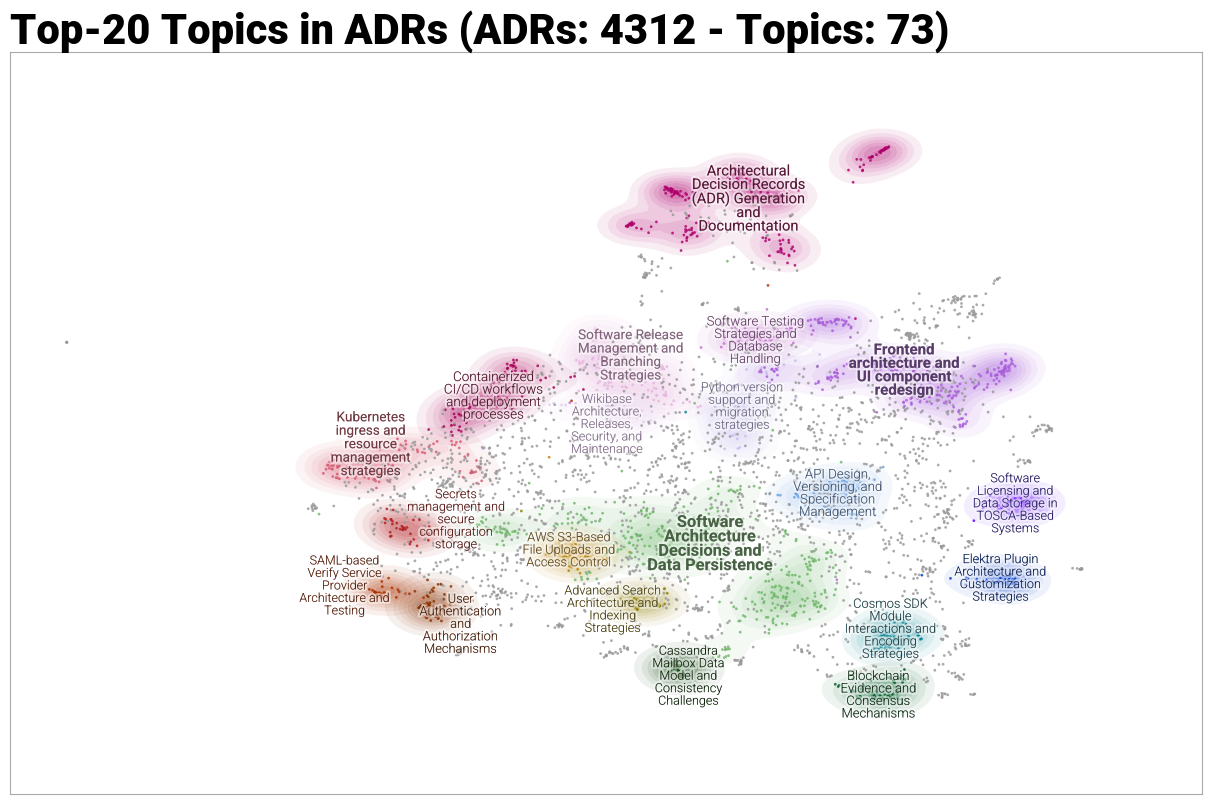

In [13]:
adr_topic_model.show_topic_map()

In [14]:
# Example of predicting the main topic for a 1 single ADR
new_doc = """Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that's already been done making these easy to use and secure by default. There's a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.""" 

adr_topic_model.predict(new_doc, multiple_topics=False)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-01-01 23:05:31,428 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


{'text': 'Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that\'s already been done making these easy to use and secure by default. There\'s a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.',
 'topics': [19],
 'keywords': [['aut

In [15]:
# Get a set of ADRs from a (random) org/project pair
adrs_to_classify = utils.get_documents_by_key(('LBHackney-IT', 'remultiform'), dict_adrs, field='raw')
adrs_to_classify

{'0001-record-architecture-decisions.md': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
 '0002-use-typescript.md': "# 2. Use TypeScript\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe want to be confident about the code we write, and for it to be\nself-documenting as much as possible.\n[TypeScript](https://www.typescriptlang.org/) is a compiled language with\noptional typing. It's a superset of JavaScript, so is familiar to developers who\nknow JavaScript. It has wide editor support.\n\nAs of writing, TypeScript is 

In [16]:
# Example of predicting the main topic for a group of ADRs (batch)
adr_topic_model.predict_batch(adrs_to_classify, organization='LBHackney-IT', project='remultiform', multiple_topics=False)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-01-01 23:05:31,713 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
Inferring topics for ADRs: 10it [00:00, 35575.10it/s]


[{'text': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
  'topics': [2],
  'keywords': [['architecture_decision_record',
    'adrs',
    'adr',
    'architectural',
    'architecture',
    'documenting',
    'documentation',
    'tools',
    'describes',
    'record']],
  'keybert_representation': ['1_fxa_jsx_framework_styles'],
  'openai_representation': ['Frontend architecture and UI component redesign'],
  'probabilities': [0.944305956363678],
  'metadata': {'organization': 'LBHackney-IT',
   'project': 'remultiform',
   'adr_key

---

In [17]:
KRUCHTEN_GROUND_TRUTH = './sample/kruchten_gt_processed1.csv'

# Load ground truth
relative_path = os.path.join('..', KRUCHTEN_GROUND_TRUTH)
df_gt = pd.read_csv(relative_path, sep=';').dropna(subset=['text', 'human', 'ADR', 'raw_text'])
print(df_gt.shape)

# Print the categories (4) covered by the ground truth
print(len(df_gt['human'].unique()), df_gt['human'].unique())
print(len(df_gt['primary_category'].unique()), df_gt['primary_category'].unique())

adr_texts = {row['ADR']: row['raw_text'] for _, row in df_gt.iterrows()}
df_gt.head()


(200, 9)
4 ['Existence (ontocrisis)' 'Executive (pericrisis)' 'Property (diacrisis)'
 'Ban/Non-Existence (anticrisis)']
4 ['Existence (ontocrisis)' 'Property (diacrisis)' 'Executive (pericrisis)'
 'Ban/Non-Existence (anticrisis)']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Existence (ontocrisis),The ADR describes the implementation of a conn...,"0,85",Existence (ontocrisis),1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Existence (ontocrisis),The ADR describes a decision to implement prov...,"0,85",Existence (ontocrisis),1.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Property (diacrisis),The ADR primarily discusses versioning strateg...,"0,80",Executive (pericrisis),0.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Existence (ontocrisis),The ADR primarily discusses decisions related ...,"0,85",Existence (ontocrisis),1.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Executive (pericrisis),The ADR discusses a process and policy change ...,"0,90",Executive (pericrisis),1.0,# Cutting release branch does not create a set...


Predicting main relevant topic for a set of ADRs (ground truth)

In [18]:
# logging.disable(logging.INFO) 
logging.getLogger('adr_topic_miner').setLevel(level=logging.CRITICAL)

# Now use batch mode to check all the ADRs for the ground truth dataset
relative_path = os.path.join('..', KRUCHTEN_GROUND_TRUTH.replace('.csv', '-topics.json'))
print(relative_path)
print(len(adr_texts), "ADRs for topic prediction")
if not os.path.isfile(relative_path):
    results = adr_topic_model.predict_batch(adr_texts, as_dict=True, multiple_topics=False)
print()

# logging.basicConfig(level=logging.INFO)
# logging.disable(logging.NOTSET)

print("Saving JSON results to", relative_path)
ADRTopicModel.save_results(results, relative_path)


.././sample/kruchten_gt_processed1-topics.json
200 ADRs for topic prediction


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

2026-01-01 23:05:33,557 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
Inferring topics for ADRs: 200it [00:00, 24274.70it/s]


Saving JSON results to .././sample/kruchten_gt_processed1-topics.json


---

## Additional visualization of BERTopic

In [17]:
topic_model = adr_topic_model.topic_model

In [18]:
topic_model.visualize_hierarchy(custom_labels=False) # Topic hierarchy to check for spurious topics (i.e., irrelevant contents)

In [19]:
# For ADR contents (only)
# topics_to_merge = [-1, 3, 22, 23] # Spurious topics (e.g., ADR template) 
# topic_model.merge_topics(corpus, topics_to_merge) # It can take a while

### Visualization of Documents

In [20]:
n_adrs = len(adr_topic_model.corpus)
n_topics = len(adr_topic_model.topics_df)
print("Number of ADRs:", n_adrs)
print("Number of topics:", n_topics)

Number of ADRs: 4312
Number of topics: 73


In [21]:
first_20_topics = adr_topic_model.get_topk_topics(20)
first_20_topics

,Topic,Count,Name,CustomName,Representation,OpenAI,Representative_Docs
0,-1,1514,-1_aws_deployment_cloud_services,Cloud Infrastructure and Deployment Decision-M...,"[aws, deployment, cloud, services, platform, s...",[Cloud Infrastructure and Deployment Decision-...,NaN
1,0,407,0_publishing_database_metadata_api,Software Architecture Decisions and Data Persi...,"[publishing, database, metadata, api, db, stor...",[Software Architecture Decisions and Data Pers...,NaN
2,1,257,1_fxa_jsx_framework_styles,Frontend architecture and UI component redesign,"[fxa, jsx, framework, styles, react, webpack, ...",[Frontend architecture and UI component redesign],NaN
3,2,213,2_architecture_decision_record_adrs_adr_archit...,Architectural Decision Records (ADR) Generatio...,"[architecture_decision_record, adrs, adr, arch...",[Architectural Decision Records (ADR) Generati...,NaN
4,3,109,3_kubernetes_kubectl_pods_pod,Kubernetes ingress and resource management str...,"[kubernetes, kubectl, pods, pod, ingress, aws,...",[Kubernetes ingress and resource management st...,NaN
5,4,108,4_branches_releases_branching_branch,Software Release Management and Branching Stra...,"[branches, releases, branching, branch, commit...",[Software Release Management and Branching Str...,NaN
6,5,100,5_docker_dockerfiles_dockerfile_containers,Containerized CI/CD workflows and deployment p...,"[docker, dockerfiles, dockerfile, containers, ...",[Containerized CI/CD workflows and deployment ...,NaN
7,6,84,6_apis_api_swagger_openapi,"API Design, Versioning, and Specification Mana...","[apis, api, swagger, openapi, documentation, s...","[API Design, Versioning, and Specification Man...",NaN
8,7,69,7_testcontainers_testing_tests_testharness,Software Testing Strategies and Database Handling,"[testcontainers, testing, tests, testharness, ...",[Software Testing Strategies and Database Hand...,NaN
9,8,68,8_evidence_attacks_validators_consensus,Blockchain Evidence and Consensus Mechanisms,"[evidence, attacks, validators, consensus, pro...",[Blockchain Evidence and Consensus Mechanisms],NaN


In [22]:
# embeddings = adr_topic_model.embedding_model.encode(adr_topic_model.corpus, show_progress_bar=True)

# It works only if the number of topics is not too high
# topic_model.visualize_document_datamap(adr_topic_model.corpus, embeddings=embeddings, 
#                                        interactive=True, custom_labels=True, topics=first_20_topics,
#                                        topic_prefix=True, enable_search=True, title="Top-20 Topics in ADRs") 

### Visualization of Topics

In [23]:
fig = topic_model.visualize_topics(custom_labels=True, title="Topic Mapping (Top 20 Topics)", top_n_topics=20) 
fig

In [24]:
topic_model.visualize_barchart(custom_labels=False, top_n_topics=20, title="Top 20 Topics in ADRs") # It can be saved as a PNG file

In [25]:
topic_model.visualize_heatmap() # Topic similarity

### Hierarchies

In [26]:
topic_model.visualize_hierarchy(custom_labels=False) # Topic hierarchy

### World Cloud

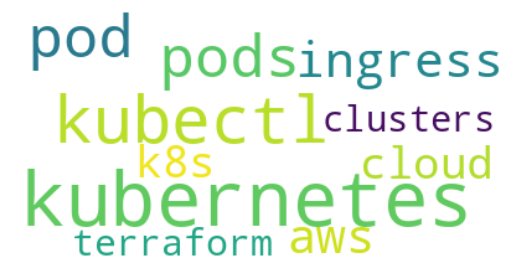

In [27]:
# Show wordcloud
adr_topic_model.show_wordcloud(topic_id=3)

In [1]:
# New documents to predict
new_doc = """Date: 2017-07-25 Accepted Verify have a number of pre-existing (closed source) libraries at various levels of abstraction for handling SAML behaviour. By depending on these we can benefit from all the work that's already been done making these easy to use and secure by default. There's a plan in the medium term to open source a lot of these libraries. By depending on as few of them as possible we should be able to call the verify-service-provider "fully open" sooner. Some of the libraries at higher levels of abstraction are of questionable value - although they make it easy to be consistent with the rest of verify they abstract away the exact nature of the SAML which makes the code hard to read. Good libraries that we should use for now: saml-serialisers ida-saml-extensions saml-security saml-metadata-bindings Libraries we think we should ignore hub-saml We may have to inline some bits of e.g. hub-saml, or reimplement them differently.""" 
result = adr_topic_model.predict(new_doc, as_dict=False)

color_name_markdown = '<span style="color: orange;">' + new_doc + '</span>'
display(Markdown(color_name_markdown))

print(f"Topics: {result.topics}") # e.g., [0, 1]
print(f"Probabilities: {result.probabilities}") # e.g., [0.9, 0.8]
print("-----")
threshold = 0.1
labels = topic_model.get_topic_info()['CustomName'].tolist()
for topic, prob in zip(result.topics, result.probabilities):
    if prob > threshold:
        print(f"Topic {topic}: {result.keybert_representation}")
        print(f"Label: {result.openai_representation}")
        print(f"{result.keywords}")
    print("-----")

NameError: name 'adr_topic_model' is not defined

---
### Metrics

In [29]:
# Topic coherence quantifies the semantic similarity among words within a topic. 
# A high coherence score indicates that the words in a topic are closely related and likely to appear together in documents
# Coherence scores typically range from 0 to 1, with 1 representing perfect coherence and 0 representing no coherence. 
# For instance, a good coherence score might be around 0.5 or higher

# Topic diversity measures how distinct or unique different topics are from each other. 
# A high diversity score suggests that the topics capture a wide range of different aspects of the corpus.


print("Coherence=", adr_topic_model.compute_topic_coherence())
print("Diversity=", adr_topic_model.compute_topic_diversity())

Coherence= 0.36556717935158367
Diversity= 0.9958907402293208
